Shape: (438, 11)
Date range: 1990-01-01 to 2026-06-01


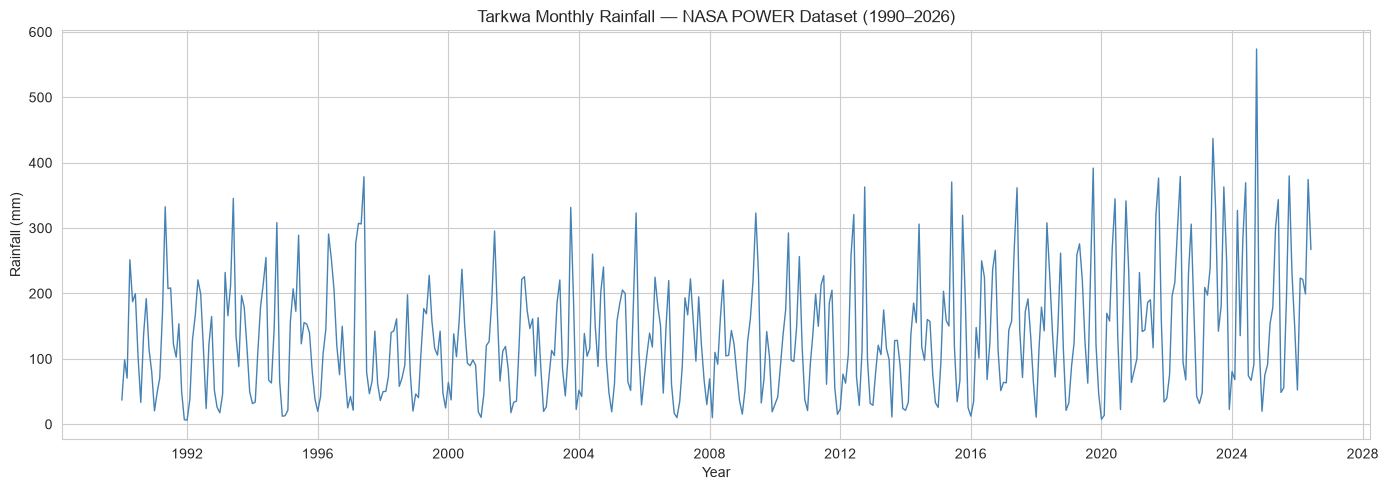

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.stattools import adfuller

sns.set_style("whitegrid")

df = pd.read_csv("../data/tarkwa_nasa_monthly.csv", parse_dates=["date"])
df = df.sort_values("date").reset_index(drop=True)

print("Shape:", df.shape)
print("Date range:", df["date"].min().date(), "to", df["date"].max().date())

plt.figure(figsize=(14, 5))
plt.plot(df["date"], df["rainfall_mm"], color="steelblue", linewidth=1)
plt.title("Tarkwa Monthly Rainfall — NASA POWER Dataset (1990–2026)")
plt.xlabel("Year")
plt.ylabel("Rainfall (mm)")
plt.tight_layout()
plt.savefig("../models/nasa_eda_timeseries.png", dpi=150)
plt.show()

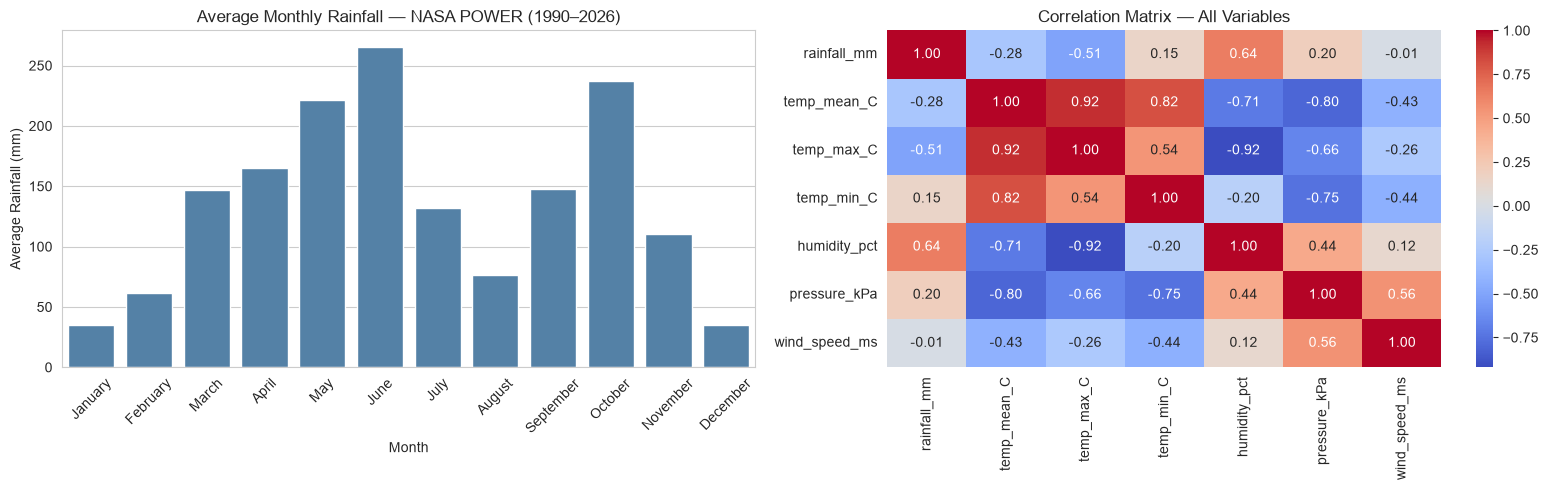


Average rainfall by month (mm):
month_name
January       35.0
February      61.9
March        146.8
April        164.9
May          221.1
June         265.7
July         132.3
August        76.7
September    147.4
October      237.0
November     110.7
December      35.1
Name: rainfall_mm, dtype: float64

Correlation of predictors with rainfall_mm:
humidity_pct     0.644
pressure_kPa     0.200
temp_min_C       0.148
wind_speed_ms   -0.007
temp_mean_C     -0.284
temp_max_C      -0.510
Name: rainfall_mm, dtype: float64


In [2]:
month_order = ["January", "February", "March", "April", "May", "June",
               "July", "August", "September", "October", "November", "December"]

monthly_avg = df.groupby("month_name")["rainfall_mm"].mean().reindex(month_order)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Monthly climatology bar chart
sns.barplot(x=monthly_avg.index, y=monthly_avg.values, color="steelblue", ax=axes[0])
axes[0].set_title("Average Monthly Rainfall — NASA POWER (1990–2026)")
axes[0].set_xlabel("Month")
axes[0].set_ylabel("Average Rainfall (mm)")
axes[0].tick_params(axis='x', rotation=45)

# Correlation heatmap between all variables and rainfall
feature_cols = ["rainfall_mm", "temp_mean_C", "temp_max_C", "temp_min_C",
                "humidity_pct", "pressure_kPa", "wind_speed_ms"]
corr = df[feature_cols].corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", ax=axes[1])
axes[1].set_title("Correlation Matrix — All Variables")

plt.tight_layout()
plt.savefig("../models/nasa_eda_climatology_corr.png", dpi=150)
plt.show()

print("\nAverage rainfall by month (mm):")
print(monthly_avg.round(1))

print("\nCorrelation of predictors with rainfall_mm:")
print(corr["rainfall_mm"].drop("rainfall_mm").sort_values(ascending=False).round(3))

In [3]:
result = adfuller(df["rainfall_mm"])

print("ADF Statistic:", round(result[0], 4))
print("p-value:", round(result[1], 4))
print("Critical values:")
for key, value in result[4].items():
    print(f"   {key}: {round(value, 4)}")

if result[1] <= 0.05:
    print("\n→ Series IS stationary (reject H0 at 5% significance)")
else:
    print("\n→ Series is NOT stationary — differencing may be needed for time-series models")

ADF Statistic: -2.032
p-value: 0.2727
Critical values:
   1%: -3.4458
   5%: -2.8683
   10%: -2.5704

→ Series is NOT stationary — differencing may be needed for time-series models
